In [1]:
import biovec

In [2]:
model = biovec.models.ProtVec(fasta_fname="sample_dna.fasta", corpus_fname="samp_dna_corpus.txt")
model.multiseq_to_vecs("sample_dna.fasta", "sample-dna-protvec", seqtype="nucleotide")
model.save('trained_models/sample-dna-protvec.model')

Generate Corpus file from fasta file...


corpus generation progress: 100%|██████████| 547772/547772 [00:09<00:00, 56489.12it/s]


Number of sequences in the input file :  547772
cannot output protvec representation for  Seq10,198251


In [ ]:
pv = biovec.models.load_protvec('trained_models/sample-dna-protvec.model')

In [ ]:
print("Top 10 Other Similar Words")
print(pv.wv.most_similar('ACT', topn=10))
print(f"Cosine Similarity between nucleotides 'ACT' and 'TGA': {pv.wv.similarity('ACT', 'TGA')}")

Top 10 Other Similar Words
[('ACA', 0.6220279932022095), ('CAC', 0.5963416695594788), ('CTG', 0.5764554738998413), ('ACG', 0.5701355338096619), ('ACC', 0.563713788986206), ('CTA', 0.5389692187309265), ('CTT', 0.5333915948867798), ('TAC', 0.5247716903686523), ('AAC', 0.521934449672699), ('CTC', 0.5209919810295105)]
Cosine Similarity between nucleotides 'ACT' and 'TGA': 0.36893585016450103


In [ ]:
def sequence_to_vec(seq, model):
    try:
        vec = model.to_vecs(seq) # (3, 100) n-gram dimension
        return vec.flatten()  # 1D vector of n-grams (300, 0)
    except Exception as e:
        print(f"Failed for sequence {seq}: {e}")
        return None

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("dna_melt_temp.csv")
df.head(5)

,Sequence,Oligo Concentration (M),Salt Concentration (M),pH,GC Content,Experimental Temperature
0,CCGG,0.0001,1.0,7,1.0000,16.6
1,CGCG,0.0001,1.0,7,1.0000,23.7
2,GCGC,0.0001,1.0,7,1.0000,27.5
3,CCGCGG,0.0001,1.0,7,1.0000,55.2
4,CGATCG,0.0001,1.0,7,0.6667,34.3


In [ ]:
vectors = df['Sequence'].apply(lambda x: sequence_to_vec(x, pv)) # Series
indices = vectors.apply(lambda x: x is not None) # Boolean Vector
X = np.stack(vectors[indices].values) #2D Matrix
y = df.loc[indices, "Experimental Temperature"].values #1D Array

In [ ]:
# Run the following lines individually, what are these vectors suppose to represent?
# X
# X[0]
# y[0]
# y

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")

R² Score: -80371233923247808.00
MSE: 20722673288791527424.00


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = RandomForestRegressor()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
# print(classification_report(y_test, y_pred))

R² Score: 0.79
MSE: 52.95
MAE: 6.14


In [ ]:
print(type(y_train))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


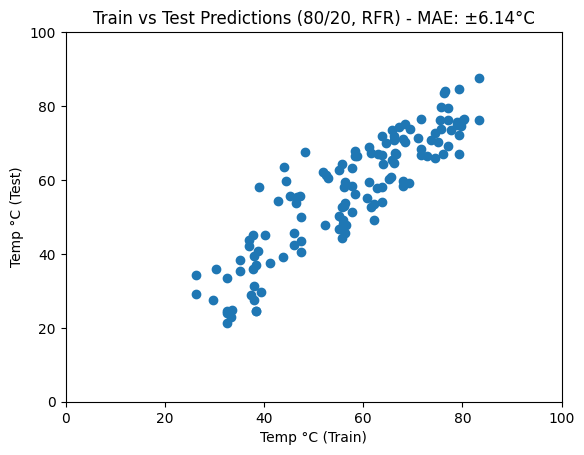

In [ ]:
import matplotlib.pyplot as plt

plt.xlabel("Temp °C (Train)")
plt.ylabel("Temp °C (Test)")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title(f"Train vs Test Predictions (80/20, RFR) - MAE: ±{mean_absolute_error(y_test, y_pred):.2f}°C")
plt.scatter(y_pred, y_test)
